In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('simulated_crop_price_dataset.csv')

In [3]:
data.head()

,Date,Crop,Region,Mandi,Price,Rainfall,Temperature,Humidity,Festival,Season,Day_of_Week,Price_7d_ahead
0,01-01-2023,Potato,West Bengal,Siliguri Mandi,2502.83,25.05,16.68,86.49,Yes,Kharif,Sunday,2372.06
1,02-01-2023,Tomato,West Bengal,Siliguri Mandi,1247.99,47.47,26.07,32.69,Yes,Summer,Monday,1090.46
2,03-01-2023,Tomato,Punjab,Ludhiana Mandi,3424.45,78.75,29.06,67.19,No,Kharif,Tuesday,3276.90
3,04-01-2023,Wheat,West Bengal,Siliguri Mandi,1673.59,33.69,31.52,41.04,No,Rabi,Wednesday,1565.96
4,05-01-2023,Wheat,West Bengal,Kolkata Mandi,1604.52,70.13,20.19,88.32,No,Kharif,Thursday,1533.52


In [4]:
df = data.copy()

In [5]:
df.head()

,Date,Crop,Region,Mandi,Price,Rainfall,Temperature,Humidity,Festival,Season,Day_of_Week,Price_7d_ahead
0,01-01-2023,Potato,West Bengal,Siliguri Mandi,2502.83,25.05,16.68,86.49,Yes,Kharif,Sunday,2372.06
1,02-01-2023,Tomato,West Bengal,Siliguri Mandi,1247.99,47.47,26.07,32.69,Yes,Summer,Monday,1090.46
2,03-01-2023,Tomato,Punjab,Ludhiana Mandi,3424.45,78.75,29.06,67.19,No,Kharif,Tuesday,3276.90
3,04-01-2023,Wheat,West Bengal,Siliguri Mandi,1673.59,33.69,31.52,41.04,No,Rabi,Wednesday,1565.96
4,05-01-2023,Wheat,West Bengal,Kolkata Mandi,1604.52,70.13,20.19,88.32,No,Kharif,Thursday,1533.52


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2000 non-null   object 
 1   Crop            2000 non-null   object 
 2   Region          2000 non-null   object 
 3   Mandi           2000 non-null   object 
 4   Price           2000 non-null   float64
 5   Rainfall        2000 non-null   float64
 6   Temperature     2000 non-null   float64
 7   Humidity        2000 non-null   float64
 8   Festival        2000 non-null   object 
 9   Season          2000 non-null   object 
 10  Day_of_Week     2000 non-null   object 
 11  Price_7d_ahead  2000 non-null   float64
dtypes: float64(5), object(7)
memory usage: 187.6+ KB


In [7]:
df.isnull().sum()

Date              0
Crop              0
Region            0
Mandi             0
Price             0
Rainfall          0
Temperature       0
Humidity          0
Festival          0
Season            0
Day_of_Week       0
Price_7d_ahead    0
dtype: int64

In [8]:
df.describe()

,Price,Rainfall,Temperature,Humidity,Price_7d_ahead
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2511.168595,49.390120,27.490180,59.327565,2506.818040
std,845.607900,28.348196,7.265479,17.191975,867.094168
min,1000.850000,0.080000,15.010000,30.000000,766.380000
25%,1770.007500,24.897500,21.125000,44.610000,1769.832500
50%,2517.535000,50.200000,27.350000,59.235000,2535.825000
75%,3247.987500,73.052500,33.660000,73.922500,3228.272500
max,3995.980000,99.980000,40.000000,89.990000,4282.110000


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
df['Lag_1'] = df['Price'].shift(1)

In [11]:
df = df.drop(columns=['Date'])

In [12]:
df.head()

,Crop,Region,Mandi,Price,Rainfall,Temperature,Humidity,Festival,Season,Day_of_Week,Price_7d_ahead,Month,Year,Day,Lag_1
0,Potato,West Bengal,Siliguri Mandi,2502.83,25.05,16.68,86.49,Yes,Kharif,Sunday,2372.06,1,2023,1,NaN
1,Tomato,West Bengal,Siliguri Mandi,1247.99,47.47,26.07,32.69,Yes,Summer,Monday,1090.46,1,2023,2,2502.83
2,Tomato,Punjab,Ludhiana Mandi,3424.45,78.75,29.06,67.19,No,Kharif,Tuesday,3276.90,1,2023,3,1247.99
3,Wheat,West Bengal,Siliguri Mandi,1673.59,33.69,31.52,41.04,No,Rabi,Wednesday,1565.96,1,2023,4,3424.45
4,Wheat,West Bengal,Kolkata Mandi,1604.52,70.13,20.19,88.32,No,Kharif,Thursday,1533.52,1,2023,5,1673.59


In [13]:
df['Lag_1'] = df['Lag_1'].fillna(df['Lag_1'].mean())

In [14]:
df.head()

,Crop,Region,Mandi,Price,Rainfall,Temperature,Humidity,Festival,Season,Day_of_Week,Price_7d_ahead,Month,Year,Day,Lag_1
0,Potato,West Bengal,Siliguri Mandi,2502.83,25.05,16.68,86.49,Yes,Kharif,Sunday,2372.06,1,2023,1,2510.807169
1,Tomato,West Bengal,Siliguri Mandi,1247.99,47.47,26.07,32.69,Yes,Summer,Monday,1090.46,1,2023,2,2502.830000
2,Tomato,Punjab,Ludhiana Mandi,3424.45,78.75,29.06,67.19,No,Kharif,Tuesday,3276.90,1,2023,3,1247.990000
3,Wheat,West Bengal,Siliguri Mandi,1673.59,33.69,31.52,41.04,No,Rabi,Wednesday,1565.96,1,2023,4,3424.450000
4,Wheat,West Bengal,Kolkata Mandi,1604.52,70.13,20.19,88.32,No,Kharif,Thursday,1533.52,1,2023,5,1673.590000


In [34]:
df.shape

(2000, 16)

In [15]:
df['Price_Change'] = df['Price'].diff()

In [16]:
df.head()

,Crop,Region,Mandi,Price,Rainfall,Temperature,Humidity,Festival,Season,Day_of_Week,Price_7d_ahead,Month,Year,Day,Lag_1,Price_Change
0,Potato,West Bengal,Siliguri Mandi,2502.83,25.05,16.68,86.49,Yes,Kharif,Sunday,2372.06,1,2023,1,2510.807169,NaN
1,Tomato,West Bengal,Siliguri Mandi,1247.99,47.47,26.07,32.69,Yes,Summer,Monday,1090.46,1,2023,2,2502.830000,-1254.84
2,Tomato,Punjab,Ludhiana Mandi,3424.45,78.75,29.06,67.19,No,Kharif,Tuesday,3276.90,1,2023,3,1247.990000,2176.46
3,Wheat,West Bengal,Siliguri Mandi,1673.59,33.69,31.52,41.04,No,Rabi,Wednesday,1565.96,1,2023,4,3424.450000,-1750.86
4,Wheat,West Bengal,Kolkata Mandi,1604.52,70.13,20.19,88.32,No,Kharif,Thursday,1533.52,1,2023,5,1673.590000,-69.07


In [17]:
df['Price_Change'] = df['Price_Change'].fillna(df['Price_Change'].mean())

In [18]:
df.head()

,Crop,Region,Mandi,Price,Rainfall,Temperature,Humidity,Festival,Season,Day_of_Week,Price_7d_ahead,Month,Year,Day,Lag_1,Price_Change
0,Potato,West Bengal,Siliguri Mandi,2502.83,25.05,16.68,86.49,Yes,Kharif,Sunday,2372.06,1,2023,1,2510.807169,0.365598
1,Tomato,West Bengal,Siliguri Mandi,1247.99,47.47,26.07,32.69,Yes,Summer,Monday,1090.46,1,2023,2,2502.830000,-1254.840000
2,Tomato,Punjab,Ludhiana Mandi,3424.45,78.75,29.06,67.19,No,Kharif,Tuesday,3276.90,1,2023,3,1247.990000,2176.460000
3,Wheat,West Bengal,Siliguri Mandi,1673.59,33.69,31.52,41.04,No,Rabi,Wednesday,1565.96,1,2023,4,3424.450000,-1750.860000
4,Wheat,West Bengal,Kolkata Mandi,1604.52,70.13,20.19,88.32,No,Kharif,Thursday,1533.52,1,2023,5,1673.590000,-69.070000


In [19]:
df.describe()

,Price,Rainfall,Temperature,Humidity,Price_7d_ahead,Month,Year,Day,Lag_1,Price_Change
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2511.168595,49.390120,27.490180,59.327565,2506.818040,6.250500,2025.260500,15.680000,2510.807169,0.365598
std,845.607900,28.348196,7.265479,17.191975,867.094168,3.447563,1.594337,8.788528,845.453407,1194.611771
min,1000.850000,0.080000,15.010000,30.000000,766.380000,1.000000,2023.000000,1.000000,1000.850000,-2884.200000
25%,1770.007500,24.897500,21.125000,44.610000,1769.832500,3.000000,2024.000000,8.000000,1770.007500,-848.630000
50%,2517.535000,50.200000,27.350000,59.235000,2535.825000,6.000000,2025.000000,16.000000,2514.980000,-0.890000
75%,3247.987500,73.052500,33.660000,73.922500,3228.272500,9.000000,2027.000000,23.000000,3247.987500,816.657500
max,3995.980000,99.980000,40.000000,89.990000,4282.110000,12.000000,2028.000000,31.000000,3995.980000,2923.210000


In [20]:
X = df.drop(columns = ['Price_7d_ahead'])
y = df['Price_7d_ahead']

In [21]:
y.head()

0    2372.06
1    1090.46
2    3276.90
3    1565.96
4    1533.52
Name: Price_7d_ahead, dtype: float64

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train , X_test ,y_train , y_test = train_test_split(X,y,
                                                      test_size = 0.3,
                                                      random_state=42)

<Axes: xlabel='Price', ylabel='Density'>

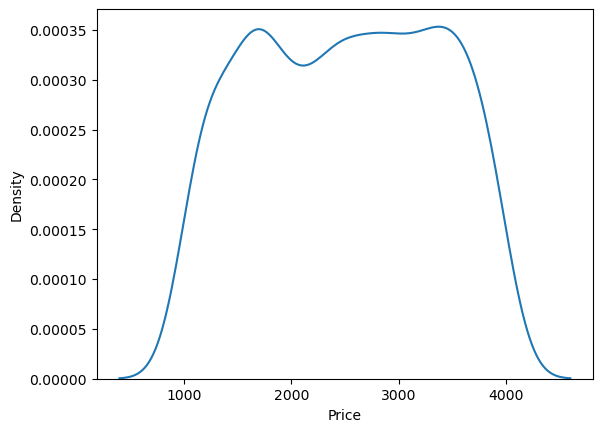

In [24]:
sns.kdeplot(X_train['Price'])

In [25]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

In [26]:
trf1 = ColumnTransformer([
    ('ordinal', OrdinalEncoder(categories=[
        ['Kharif', 'Rabi', 'Summer']]), [8]),
    ('ohe' , OneHotEncoder( sparse_output=False ) , [0,1,2,7,9]),
    ('scaler', MinMaxScaler(feature_range=(0, 1)), ['Price', 'Lag_1', 'Rainfall', 'Temperature', 'Humidity','Year','Price_Change'])
], remainder='passthrough')

In [27]:
df.sample()

,Crop,Region,Mandi,Price,Rainfall,Temperature,Humidity,Festival,Season,Day_of_Week,Price_7d_ahead,Month,Year,Day,Lag_1,Price_Change
363,Onion,West Bengal,Siliguri Mandi,3409.53,59.03,39.01,45.73,No,Summer,Saturday,3246.21,12,2023,30,1289.0,2120.53


In [28]:
trf2 = RandomForestRegressor()

In [29]:
pipe = make_pipeline(trf1 , trf2)

In [30]:
pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Kharif',
                                                                              'Rabi',
                                                                              'Summer']]),
                                                  [8]),
                                                 ('ohe',
                                                  OneHotEncoder(sparse_output=False),
                                                  [0, 1, 2, 7, 9]),
                                                 ('scaler', MinMaxScaler(),
                                                  ['Price', 'Lag_1', 'Rainfall',
                                                   'Temperature', 'Humidity',
                                                   'Year', 'Price_Change'])])),
                ('randomforestregressor', RandomForestRegressor())])

In [31]:
y_pred = pipe.predict(X_test)

In [32]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error

In [33]:
print("R2 Score : " , r2_score(y_test , y_pred))
print("MSE : " , mean_squared_error(y_test,y_pred))
print("RMSE : " ,np.sqrt(mean_squared_error(y_test , y_pred)))
pritn("MAE : " , mean_absolute_error(y_test , y_pred))

R2 Score :  0.952118291919472
MSE :  34615.998015511635
RMSE :  186.05375033981883
MAE :  159.59477449999997
